In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- SUA ESTRUTURA DE DIRETÓRIOS E CAPTURA ---
ROOT_DIR = "drive/MyDrive/heatmaps"  # Ajuste para a sua pasta raiz
patient_dict = {"Healthy": {}, "Sick": {}}
classes = ["Healthy", "Sick"]

for classe in classes:
    class_path = os.path.join(ROOT_DIR, classe)
    label = 0 if classe == "Healthy" else 1

    if not os.path.exists(class_path):
        continue

    for paciente in os.listdir(class_path):
        paciente_path = os.path.join(class_path, paciente)
        if not os.path.isdir(paciente_path):
            continue

        patient_images = []

        for visita in os.listdir(paciente_path):
            visita_path = os.path.join(paciente_path, visita, "images", "thermography")

            for modo in ["static", "dynamic"]:
                modo_path = os.path.join(visita_path, modo)
                if not os.path.exists(modo_path):
                    continue

                for file in os.listdir(modo_path):
                    if not file.lower().endswith(".jpg"):
                        continue

                    nome = os.path.splitext(file)[0]
                    partes = nome.split(".")

                    if len(partes) < 5:
                        continue

                    codigo = f"{partes[1]}.{partes[2]}"
                    if codigo != "1.1":
                        continue

                    image_path = os.path.join(modo_path, file)
                    patient_images.append((image_path, label))

        patient_dict[classe][paciente] = patient_images


In [ ]:
total_pacientes_healthy = len(patient_dict["Healthy"])
total_pacientes_sick = len(patient_dict["Sick"])

total_imagens_healthy = sum(len(fotos) for fotos in patient_dict["Healthy"].values())
total_imagens_sick = sum(len(fotos) for fotos in patient_dict["Sick"].values())

print("="*45)
print("   ESTATÍSTICAS DA BASE DE DADOS (ITEM 2.a)   ")
print("="*45)
print(f"Classe HEALTHY:")
print(f"  - Total de Pacientes Únicos: {total_pacientes_healthy}")
print(f"  - Total de Imagens Térmicas: {total_imagens_healthy}")
print(f"  - Média de imagens por paciente: {total_imagens_healthy/total_pacientes_healthy:.1f}" if total_pacientes_healthy > 0 else 0)
print("-"*45)
print(f"Classe SICK:")
print(f"  - Total de Pacientes Únicos: {total_pacientes_sick}")
print(f"  - Total de Imagens Térmicas: {total_imagens_sick}")
print(f"  - Média de imagens por paciente: {total_imagens_sick/total_pacientes_sick:.1f}" if total_pacientes_sick > 0 else 0)
print("="*45)
print(f"TOTAL GERAL: {total_pacientes_healthy + total_pacientes_sick} pacientes | {total_imagens_healthy + total_imagens_sick} imagens")
print("="*45)

   ESTATÍSTICAS DA BASE DE DADOS (ITEM 2.a)   
Classe HEALTHY:
  - Total de Pacientes Únicos: 192
  - Total de Imagens Térmicas: 3454
  - Média de imagens por paciente: 18.0
---------------------------------------------
Classe SICK:
  - Total de Pacientes Únicos: 46
  - Total de Imagens Térmicas: 790
  - Média de imagens por paciente: 17.2
TOTAL GERAL: 238 pacientes | 4244 imagens


In [ ]:
import torch
from torchvision import transforms

IMG_SIZE = 224

# Medias e desvios padrão oficiais do ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([

    transforms.ToTensor(),

    transforms.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.9, 1.0), ratio=(0.95, 1.05)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# 2. PIPELINE DE VALIDAÇÃO E TESTE
valid_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Pipelines de transformação criados com sucesso!")

Pipelines de transformação criados com sucesso!


In [ ]:
from PIL import Image

todas_imagens = []
todos_labels = []
todos_pacientes = []

for classe in ["Healthy", "Sick"]:
    for paciente, lista_imagens in patient_dict[classe].items():
        for img_path, label in lista_imagens:
            todas_imagens.append((img_path, label))
            todos_labels.append(label)
            todos_pacientes.append(paciente)

X_paths = np.array(todas_imagens)
y_labels = np.array(todos_labels)
groups_pacientes = np.array(todos_pacientes)

# A nova classe de Dataset adaptada para o K-Fold
class KFoldTermografiaDataset(torch.utils.data.Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

master_train_dataset = KFoldTermografiaDataset(todas_imagens, transform=train_transforms)
master_val_dataset = KFoldTermografiaDataset(todas_imagens, transform=valid_transforms)

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader, Subset
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
import torch.optim as optim
import timm
import copy

from tqdm.auto import tqdm

todos_os_labels_gerais = []
todas_as_preds_gerais = []

sgkf = StratifiedGroupKFold(n_splits=5)
epochs_por_fold = 10
historico_dos_folds = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Iniciando Validação Cruzada (5-Fold)...")

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_paths, y_labels, groups_pacientes)):
    print(f"\n======== TREINANDO O FOLD {fold+1}/5 ========")

    train_subset = Subset(master_train_dataset, train_idx)
    val_subset = Subset(master_val_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True, num_workers=2,)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False, num_workers=2)

    labels_treino_fold = y_labels[train_idx]
    class_weights = compute_class_weight('balanced', classes=np.unique(labels_treino_fold), y=labels_treino_fold)
    pesos_classes = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=pesos_classes)

    model = timm.create_model(
        'densenet121',
        pretrained=True,
        num_classes=2,
        drop_rate=0.3
    )

    model.to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=3e-5,
        weight_decay=0.1
    )

    fold_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_acc = 0
    best_preds = None
    best_labels = None
    best_weights = None

    # Épocas
    for epoch in range(epochs_por_fold):

        preds_epoch = []
        labels_epoch = []

        model.train()

        pbar = tqdm(train_loader, desc=f"Fold {fold+1} | Epoch {epoch+1}")
        train_loss, train_correct, train_total = 0.0, 0, 0
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            pbar.set_postfix(loss=loss.item())

            train_loss += loss.item() * imgs.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()


        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * imgs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

                preds_epoch.extend(predicted.cpu().numpy())
                labels_epoch.extend(labels.cpu().numpy())
                # todas_as_preds_gerais.extend(predicted.cpu().numpy())
                # todos_os_labels_gerais.extend(labels.cpu().numpy())

        val_acc = val_correct / val_total
        val_loss = val_loss / val_total
        train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        if val_acc > best_acc:
          best_acc = val_acc
          best_weights = copy.deepcopy(model.state_dict())
          best_preds = preds_epoch.copy()
          best_labels = labels_epoch.copy()

        fold_history['train_loss'].append(train_loss)
        fold_history['val_loss'].append(val_loss)
        fold_history['train_acc'].append(train_acc)
        fold_history['val_acc'].append(val_acc)

    todas_as_preds_gerais.extend(best_preds)
    todos_os_labels_gerais.extend(best_labels)

    print(f"Fold {fold+1} Concluído! Melhor Acc Val: {max(fold_history['val_acc'])*100:.1f}%")
    historico_dos_folds.append(fold_history)
    print(f"Labels: {len(todos_os_labels_gerais)}")
    print(f"Preds: {len(todas_as_preds_gerais)}")

Iniciando Validação Cruzada (5-Fold)...

======== TREINANDO O FOLD 1/5 ========


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

Fold 1 | Epoch 1:   0%|          | 0/212 [00:00<?, ?it/s]

Fold 1 | Epoch 2:   0%|          | 0/212 [00:00<?, ?it/s]

...

Fold 5 | Epoch 7:   0%|          | 0/213 [00:00<?, ?it/s]

Fold 5 | Epoch 8:   0%|          | 0/213 [00:00<?, ?it/s]

Fold 5 | Epoch 9:   0%|          | 0/213 [00:00<?, ?it/s]

Fold 5 | Epoch 10:   0%|          | 0/213 [00:00<?, ?it/s]

Fold 5 Concluído! Melhor Acc Val: 87.4%
Labels: 4244
Preds: 4244



       RELATORIO DE CLASSIFICAÇÃO       
              precision    recall  f1-score   support

     Healthy       0.91      0.94      0.92      3454
        Sick       0.69      0.57      0.62       790

    accuracy                           0.87      4244
   macro avg       0.80      0.75      0.77      4244
weighted avg       0.86      0.87      0.87      4244



<Axes: >

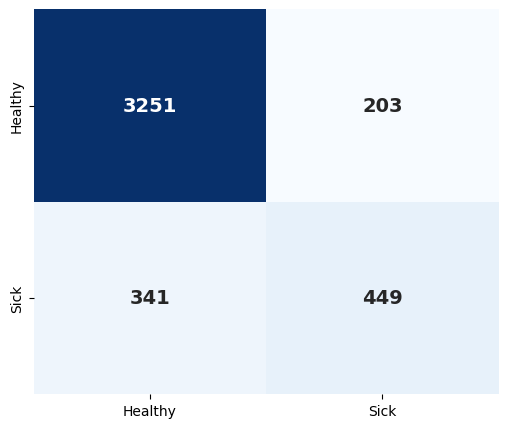

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("       RELATORIO DE CLASSIFICAÇÃO       ")
print("="*60)
print(classification_report(todos_os_labels_gerais, todas_as_preds_gerais, target_names=["Healthy", "Sick"]))
print("="*60)


plt.figure(figsize=(6, 5))
cm_consolidada = confusion_matrix(todos_os_labels_gerais, todas_as_preds_gerais)

sns.heatmap(cm_consolidada, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Healthy", "Sick"], yticklabels=["Healthy", "Sick"],
            cbar=False, annot_kws={"size": 14, "weight": "bold"})


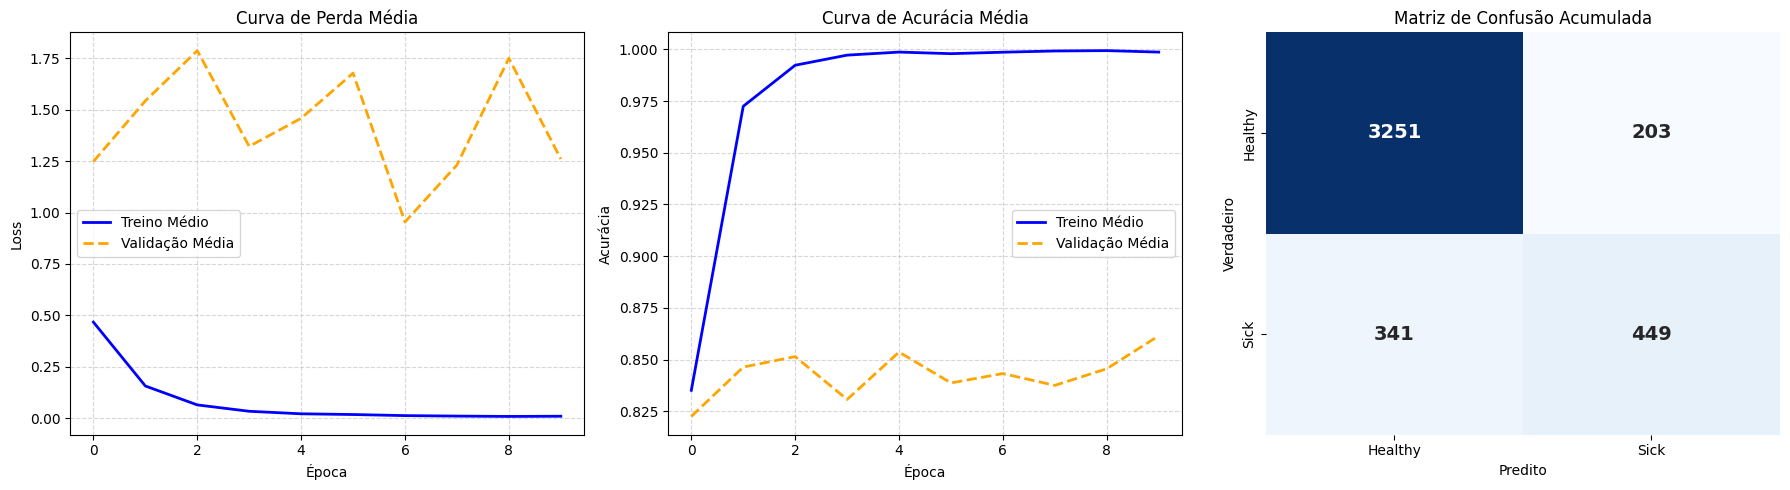

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Extrair e tirar a média das curvas de Loss e Acc de todos os 5 folds
num_epochs = len(historico_dos_folds[0]['train_loss'])

media_train_loss = np.mean([f['train_loss'] for f in historico_dos_folds], axis=0)
media_val_loss = np.mean([f['val_loss'] for f in historico_dos_folds], axis=0)
media_train_acc = np.mean([f['train_acc'] for f in historico_dos_folds], axis=0)
media_val_acc = np.mean([f['val_acc'] for f in historico_dos_folds], axis=0)

# 2. Configurar a figura tripla (igual à sua ideia original)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(media_train_loss, label='Treino Médio', color='blue', linewidth=2)
axes[0].plot(media_val_loss, label='Validação Média', color='orange', linewidth=2, linestyle='--')
axes[0].set_title('Curva de Perda Média')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Acurácia
axes[1].plot(media_train_acc, label='Treino Médio', color='blue', linewidth=2)
axes[1].plot(media_val_acc, label='Validação Média', color='orange', linewidth=2, linestyle='--')
axes[1].set_title('Curva de Acurácia Média')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# Matriz de Confusão
cm_consolidada = confusion_matrix(todos_os_labels_gerais, todas_as_preds_gerais)
sns.heatmap(cm_consolidada, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=["Healthy", "Sick"], yticklabels=["Healthy", "Sick"],
            cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[2].set_title('Matriz de Confusão Acumulada')
axes[2].set_xlabel('Predito')
axes[2].set_ylabel('Verdadeiro')

plt.tight_layout()
plt.show()